# Isochrons in corner stagnation flow

This notebook asks whether the analytical corner flow in [`bradlipovsky/wedge`](https://github.com/bradlipovsky/wedge/blob/main/stagnation.ipynb) forms recumbent isochrons. The difficulty is not particle advection. It is deciding what age the particles carry when they enter the corner.

I separate three questions. First, what do contours of time since entry look like? Second, does the flow overturn inherited horizontal material layers? Third, if horizontal layers do not overturn, what initial layer dip would be rotated through vertical? This separation avoids choosing one complicated initial fold by inspection. The calculation is dimensionless and kinematic; it is not a fit to ALHIC1901.

## Prescribed flow and boundary conditions

The domain is a wedge $0<r<R$ and $0<\theta<\alpha$. I use the streamfunction

$$
\psi=-r^\lambda\sin(\lambda\theta),
\qquad \lambda=\frac{2\pi}{\alpha},
$$

with $R=1$ and $\alpha=3\pi/4=135^\circ$, as in the source notebook. The velocity scale is the speed $U_R=|A|\lambda R^{\lambda-1}$ at a sidewall on the outer arc. Time is reported as $\tau=tU_R/R$. Thus $\tau=1$ would be 1 kyr if $R=1$ km and $U_R=1$ m yr$^{-1}$.

Both wedge sides are streamlines, so they are impermeable. Their tangential speed is nonzero, however, so these are slip rather than no-slip boundaries. The circular boundary $r=1$ is open. Flow enters through $0<\theta<\alpha/4$ and $3\alpha/4<\theta<\alpha$, and leaves through the middle half of the arc. The ray $\theta=\alpha/2=67.5^\circ$ is an outgoing separatrix. Speed vanishes at the corner.

This field is two-dimensional, steady, incompressible, and irrotational. It is used only as a prescribed velocity. It contains no free surface, gravity-driven stress, no-slip bed, or out-of-plane escape.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import hyp2f1

alpha = 3 * np.pi / 4
lam = 2 * np.pi / alpha
velocity_power = lam - 1
outer_radius = 1.0

print(f"Wedge angle: {np.degrees(alpha):.1f} degrees")
print(f"Streamfunction exponent lambda: {lam:.3f}")
print(f"Outgoing separatrix: {np.degrees(alpha / 2):.1f} degrees")

Wedge angle: 135.0 degrees
Streamfunction exponent lambda: 2.667
Outgoing separatrix: 67.5 degrees


In [2]:
def velocity(points):
    """Dimensionless Cartesian velocity at points shaped (n, 2)."""
    x, y = points[:, 0], points[:, 1]
    r = np.hypot(x, y)
    theta = np.arctan2(y, x)
    speed_factor = r**velocity_power
    u = -speed_factor * np.cos(velocity_power * theta)
    w = speed_factor * np.sin(velocity_power * theta)
    return np.column_stack((u, w))


def velocity_gradient(points):
    """Gradient L_ij = d u_i / d x_j of the dimensionless flow."""
    x, y = points[:, 0], points[:, 1]
    r = np.hypot(x, y)
    theta = np.arctan2(y, x)
    amplitude = velocity_power * r**(velocity_power - 1)
    a = amplitude * np.cos((velocity_power - 1) * theta)
    b = amplitude * np.sin((velocity_power - 1) * theta)
    gradient = np.empty((len(points), 2, 2))
    gradient[:, 0, 0] = -a
    gradient[:, 0, 1] = b
    gradient[:, 1, 0] = b
    gradient[:, 1, 1] = a
    return gradient


def inside_wedge(points):
    r = np.hypot(points[:, 0], points[:, 1])
    theta = np.arctan2(points[:, 1], points[:, 0])
    return (r <= outer_radius) & (theta >= 0) & (theta <= alpha)


def draw_wedge(ax):
    theta = np.linspace(0, alpha, 300)
    ax.plot(np.cos(theta), np.sin(theta), color="0.1", lw=1.5)
    ax.plot([0, 1], [0, 0], color="0.1", lw=1.5)
    ax.plot([0, np.cos(alpha)], [0, np.sin(alpha)], color="0.1", lw=1.5)
    ax.set(xlim=(-0.74, 1.03), ylim=(-0.02, 1.03), xlabel="$x/R$", ylabel="$z/R$")
    ax.set_aspect("equal")


def travel_time(phi, psi):
    """Time from the inflow arc to potential coordinate phi."""
    abs_psi = np.abs(psi)
    exponent = 1 - 1 / lam

    def primitive(q):
        ratio = q / abs_psi
        return q * abs_psi**(-2 * exponent) * hyp2f1(0.5, exponent, 1.5, -ratio**2)

    phi_in = -np.sqrt(1 - psi**2)
    return (primitive(phi) - primitive(phi_in)) / lam


def residence_mesh(sign, n_streamlines=180, n_along=281):
    """Curvilinear mesh for one of the two source branches."""
    abs_psi = np.geomspace(0.002, 0.995, n_streamlines)
    progress = np.linspace(0, 1, n_along)
    psi = sign * abs_psi[:, None] * np.ones((1, n_along))
    phi_limit = np.sqrt(1 - abs_psi[:, None]**2)
    phi = (-1 + 2 * progress[None, :]) * phi_limit

    radius = np.hypot(phi, psi)**(1 / lam)
    mapped_angle = np.mod(np.arctan2(-psi, -phi), 2 * np.pi)
    theta = mapped_angle / lam
    x = radius * np.cos(theta)
    z = radius * np.sin(theta)
    return x, z, travel_time(phi, psi)

## Limiting case 1: a clock started on the inflow arc

A steady material age $T$ satisfies $\mathbf{u}\mathbin{\cdot}\nabla T=1$. If every point on both inflow arcs is assigned $T=0$, then $T$ is simply time since entry. This boundary condition deliberately maximizes the corner-flow signal: it assumes that the full thickness entering from two separate source regions has one age. It is therefore a residence-time experiment, not yet a model of deposited isochrons.

The velocity potential $\phi=-r^\lambda\cos(\lambda\theta)$ increases along a streamline, while $\psi$ is constant. The dimensionless travel time is

$$
T(\phi,\psi)=\frac{1}{\lambda}
\int_{-\sqrt{1-\psi^2}}^\phi
(q^2+\psi^2)^{-(1-1/\lambda)}\,\mathrm{d}q.
$$

Near the separatrix, the full residence time scales as $T_{res}\sim|\psi|^{2/\lambda-1}$. For $\lambda=8/3$, the predicted exponent is $-1/4$: particles arbitrarily close to the zero-speed corner are arbitrarily old.

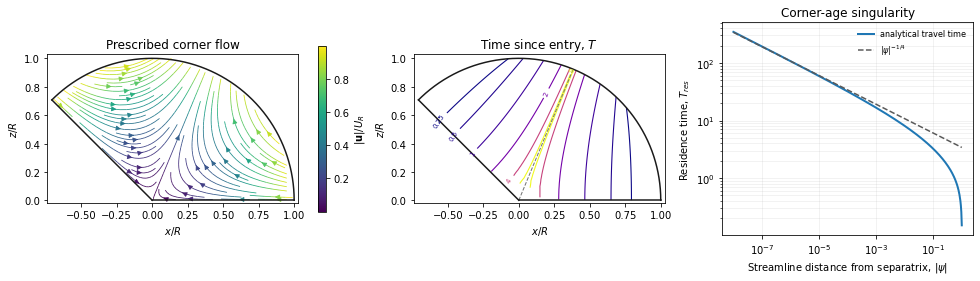

Small-|psi| fitted residence-time exponent: -0.254
Analytical asymptote: -0.250


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8), constrained_layout=True)

# Prescribed velocity.
x_grid = np.linspace(-0.72, 1.0, 260)
z_grid = np.linspace(0.005, 1.0, 220)
X, Z = np.meshgrid(x_grid, z_grid)
grid_points = np.column_stack((X.ravel(), Z.ravel()))
grid_velocity = velocity(grid_points)
valid = inside_wedge(grid_points).reshape(X.shape)
U = grid_velocity[:, 0].reshape(X.shape)
W = grid_velocity[:, 1].reshape(X.shape)
U[~valid] = np.nan
W[~valid] = np.nan
speed = np.hypot(U, W)
stream = axes[0].streamplot(x_grid, z_grid, U, W, color=speed, cmap="viridis", density=1.15, linewidth=0.8)
draw_wedge(axes[0])
axes[0].set_title("Prescribed corner flow")
fig.colorbar(stream.lines, ax=axes[0], shrink=0.78, label="$|\mathbf{u}|/U_R$")

# Equal residence-time fronts from both inflow branches.
levels = np.array([0.25, 0.5, 1, 2, 4, 8])
for sign in (-1, 1):
    x_mesh, z_mesh, time_mesh = residence_mesh(sign)
    contours = axes[1].contour(x_mesh, z_mesh, time_mesh, levels=levels, cmap="plasma", linewidths=1.1)
axes[1].clabel(contours, fmt="%g", fontsize=7)
axes[1].plot([0, np.cos(alpha / 2)], [0, np.sin(alpha / 2)], "--", color="0.45", lw=1)
draw_wedge(axes[1])
axes[1].set_title("Time since entry, $T$")

# Residence time on complete streamlines.
abs_psi = np.geomspace(1e-8, 0.98, 500)
phi_out = np.sqrt(1 - abs_psi**2)
residence = travel_time(phi_out, abs_psi)
small = abs_psi < 1e-6
fitted_exponent = np.polyfit(np.log(abs_psi[small]), np.log(residence[small]), 1)[0]
reference_index = np.argmin(np.abs(abs_psi - 1e-6))
reference = residence[reference_index] * (abs_psi / abs_psi[reference_index])**(-0.25)
axes[2].loglog(abs_psi, residence, lw=2, label="analytical travel time")
axes[2].loglog(abs_psi, reference, "--", color="0.35", label=r"$|\psi|^{-1/4}$")
axes[2].set(xlabel=r"Streamline distance from separatrix, $|\psi|$", ylabel=r"Residence time, $T_{res}$", title="Corner-age singularity")
axes[2].grid(alpha=0.2, which="both")
axes[2].legend(frameon=False, fontsize=8)
plt.show()

print(f"Small-|psi| fitted residence-time exponent: {fitted_exponent:.3f}")
print("Analytical asymptote: -0.250")

Figure 1 shows why the residence-time contours are tempting to call folds. They wrap around a narrow, very old tongue aligned with the outgoing separatrix. A vertical section can therefore encounter age increasing upward on one side of the tongue. However, the tongue is not evidence that one inherited layer has folded back on itself. It is produced by assigning one clock to two inflow branches and letting residence time diverge at their separating streamline. A material-line test is needed.

## Limiting case 2: inherited horizontal isochrons

I next fill the wedge at $\tau=0$ with horizontal material lines. Their labels can be read as an initially monotonic age, for example $A_0=1-z$. Particles that cross the open outer arc are removed; no replacement age is invented.

The deformation gradient $\mathbf{F}=\partial\mathbf{x}/\partial\mathbf{X}$ obeys

$$
\frac{\mathrm{D}\mathbf{F}}{\mathrm{D}\tau}=\mathbf{L}\mathbf{F},
\qquad \mathbf{L}=\nabla\mathbf{u},
\qquad \mathbf{F}(0)=\mathbf{I}.
$$

An initially horizontal tangent is $\mathbf{F}(1,0)^T$. It passes through vertical only if $F_{11}=0$ and is overturned if $F_{11}<0$. Relief or a large dip is not enough. Fourth-order Runge--Kutta integration advances both particles and $\mathbf{F}$.

In [4]:
def state_derivative(points, deformation):
    point_rate = velocity(points)
    deformation_rate = np.einsum("nij,njk->nik", velocity_gradient(points), deformation)
    return point_rate, deformation_rate


def rk4_step(points, deformation, step):
    p1, f1 = state_derivative(points, deformation)
    p2, f2 = state_derivative(points + step * p1 / 2, deformation + step * f1 / 2)
    p3, f3 = state_derivative(points + step * p2 / 2, deformation + step * f2 / 2)
    p4, f4 = state_derivative(points + step * p3, deformation + step * f3)
    new_points = points + step * (p1 + 2 * p2 + 2 * p3 + p4) / 6
    new_deformation = deformation + step * (f1 + 2 * f2 + 2 * f3 + f4) / 6
    return new_points, new_deformation


def integrate_flow(points_initial, output_times, step=0.01):
    points = points_initial.copy()
    deformation = np.tile(np.eye(2), (len(points), 1, 1))
    alive = np.ones(len(points), dtype=bool)
    snapshots = {}
    time = 0.0

    for target in output_times:
        while time < target - 1e-12:
            this_step = min(step, target - time)
            indices = np.flatnonzero(alive)
            points[indices], deformation[indices] = rk4_step(
                points[indices], deformation[indices], this_step
            )
            alive &= inside_wedge(points)
            time += this_step
        snapshots[target] = {
            "points": points.copy(),
            "deformation": deformation.copy(),
            "alive": alive.copy(),
        }
    return snapshots


# Horizontal material lines clipped only by the wedge boundaries.
layer_heights = np.linspace(0.04, 0.94, 19)
points_per_layer = 320
initial_lines = []
layer_ids = []
for layer_id, height in enumerate(layer_heights):
    circle_edge = np.sqrt(1 - height**2)
    left_edge = max(-circle_edge, -height)
    x_line = np.linspace(left_edge + 1e-4, circle_edge - 1e-4, points_per_layer)
    initial_lines.append(np.column_stack((x_line, np.full_like(x_line, height))))
    layer_ids.append(np.full(points_per_layer, layer_id))

line_points_initial = np.vstack(initial_lines)
layer_ids = np.concatenate(layer_ids)
line_times = [0.0, 1.0, 2.0, 4.0]
line_snapshots = integrate_flow(line_points_initial, line_times, step=0.01)

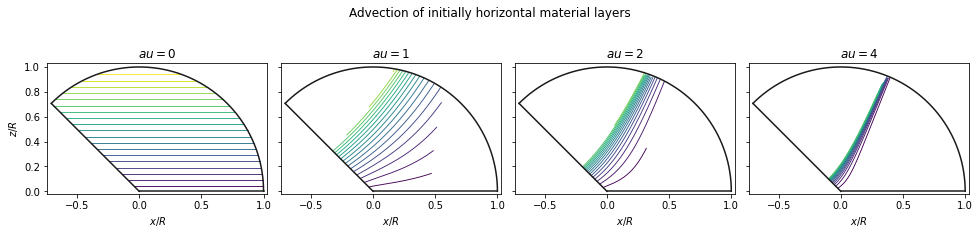

 tau   retained   min(F11)   max dip   overturned
 0.0      6080       1.000      0.0 deg       0
 1.0      2920       0.282     56.9 deg       0
 2.0      1551       0.174     68.1 deg       0
 4.0       509       0.473     68.4 deg       0


In [5]:
fig, axes = plt.subplots(1, len(line_times), figsize=(13.5, 3.2), sharex=True, sharey=True, constrained_layout=True)
line_diagnostics = []

for ax, time in zip(axes, line_times):
    snapshot = line_snapshots[time]
    points = snapshot["points"]
    deformation = snapshot["deformation"]
    alive = snapshot["alive"]

    for layer_id, height in enumerate(layer_heights):
        indices = np.flatnonzero(alive & (layer_ids == layer_id))
        groups = np.split(indices, np.flatnonzero(np.diff(indices) > 1) + 1)
        color = plt.cm.viridis((height - layer_heights.min()) / np.ptp(layer_heights))
        for group in groups:
            if len(group) > 1:
                ax.plot(points[group, 0], points[group, 1], color=color, lw=0.9)

    horizontal_tangents = deformation[alive, :, 0]
    tangent_angles = np.degrees(np.arctan2(horizontal_tangents[:, 1], horizontal_tangents[:, 0]))
    line_diagnostics.append((
        time, alive.sum(), horizontal_tangents[:, 0].min(), np.abs(tangent_angles).max(),
        np.count_nonzero(horizontal_tangents[:, 0] < 0),
    ))
    draw_wedge(ax)
    ax.set_title(f"$\tau={time:g}$")

for ax in axes[1:]:
    ax.set_ylabel("")
fig.suptitle("Advection of initially horizontal material layers")
plt.show()

print(" tau   retained   min(F11)   max dip   overturned")
for time, retained, minimum_f11, maximum_dip, overturned in line_diagnostics:
    print(f"{time:4.1f}   {retained:7d}    {minimum_f11:8.3f}   {maximum_dip:6.1f} deg   {overturned:5d}")

The corner flow makes substantial relief and rotation, but the inherited horizontal lines remain single-valued. No retained tangent has $F_{11}<0$ through $\tau=4$. Their largest dip approaches the $67.5^\circ$ outgoing separatrix rather than passing through $90^\circ$. This is a negative result for spontaneous recumbent folding from exactly horizontal stratigraphy.

## Avoiding an arbitrary initial wrinkle

A local initial tangent with dip $\beta$ is $\mathbf{t}_0=(\cos\beta,\sin\beta)$. It is vertical at a later time when

$$
F_{11}\cos\beta+F_{12}\sin\beta=0.
$$

Therefore the deformation gradient gives the critical initial dip at every point without prescribing a wrinkle shape. I calculate the smallest $|\beta|$ among particles that remain in the wedge. Initial points are kept at least $0.03R$ from both sidewalls and below $r=0.94R$ so that a boundary-grazing tangent does not set the threshold. A negative angle is a limb that descends toward the corner. This is a local necessary condition for a fold, not a mechanism for creating the seed.

 tau   smallest seed   max horizontal dip   max |det(F)-1|
 0.5       51.81 deg           40.47 deg        2.20e-10
 1.0       20.36 deg           56.84 deg        2.81e-10
 2.0        5.64 deg           67.76 deg        3.02e-10
 4.0        2.94 deg           68.80 deg        3.15e-10
Factor-of-two time-step check at tau=2: 5.6382 versus 5.6382 degrees
Factor-of-two time-step check at tau=4: 2.9364 versus 2.9364 degrees


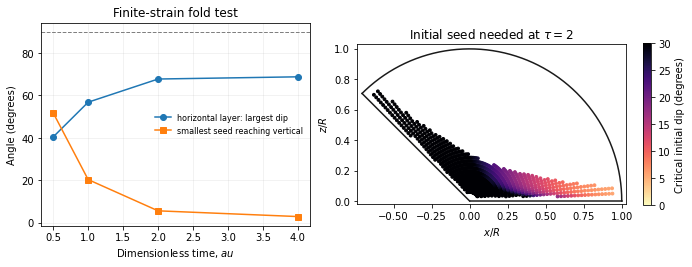

In [6]:
def critical_initial_angle(deformation):
    angle = np.degrees(np.arctan2(-deformation[:, 0, 0], deformation[:, 0, 1]))
    return (angle + 90) % 180 - 90


r_cloud = np.linspace(0.06, 0.94, 40)
theta_cloud = np.linspace(0.015, alpha - 0.015, 64)
R_cloud, Theta_cloud = np.meshgrid(r_cloud, theta_cloud, indexing="ij")
buffered = (
    (R_cloud * np.sin(Theta_cloud) > 0.03)
    & (R_cloud * np.sin(alpha - Theta_cloud) > 0.03)
)
cloud_initial = np.column_stack((
    (R_cloud * np.cos(Theta_cloud))[buffered],
    (R_cloud * np.sin(Theta_cloud))[buffered],
))
diagnostic_times = [0.5, 1.0, 2.0, 4.0]
cloud_snapshots = integrate_flow(cloud_initial, diagnostic_times, step=0.01)
fine_snapshots = integrate_flow(cloud_initial, [2.0, 4.0], step=0.005)

seed_diagnostics = []
for time in diagnostic_times:
    snapshot = cloud_snapshots[time]
    alive = snapshot["alive"]
    deformation = snapshot["deformation"][alive]
    seed_angles = critical_initial_angle(deformation)
    horizontal_angles = np.degrees(np.arctan2(deformation[:, 1, 0], deformation[:, 0, 0]))
    determinant_error = np.max(np.abs(np.linalg.det(deformation) - 1))
    seed_diagnostics.append((
        time, np.min(np.abs(seed_angles)), np.max(np.abs(horizontal_angles)), determinant_error
    ))

print(" tau   smallest seed   max horizontal dip   max |det(F)-1|")
for time, seed_angle, horizontal_angle, determinant_error in seed_diagnostics:
    print(f"{time:4.1f}      {seed_angle:6.2f} deg          {horizontal_angle:6.2f} deg        {determinant_error:.2e}")

for time in (2.0, 4.0):
    coarse = cloud_snapshots[time]
    fine = fine_snapshots[time]
    coarse_seed = np.min(np.abs(critical_initial_angle(coarse["deformation"][coarse["alive"]])))
    fine_seed = np.min(np.abs(critical_initial_angle(fine["deformation"][fine["alive"]])))
    print(f"Factor-of-two time-step check at tau={time:g}: {coarse_seed:.4f} versus {fine_seed:.4f} degrees")

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.6), constrained_layout=True)
times = np.array([row[0] for row in seed_diagnostics])
minimum_seeds = np.array([row[1] for row in seed_diagnostics])
horizontal_dips = np.array([row[2] for row in seed_diagnostics])
axes[0].plot(times, horizontal_dips, "o-", label="horizontal layer: largest dip")
axes[0].plot(times, minimum_seeds, "s-", label="smallest seed reaching vertical")
axes[0].axhline(90, ls="--", color="0.5", lw=1)
axes[0].set(xlabel="Dimensionless time, $\tau$", ylabel="Angle (degrees)", title="Finite-strain fold test")
axes[0].grid(alpha=0.2)
axes[0].legend(frameon=False, fontsize=8)

snapshot = cloud_snapshots[2.0]
alive = snapshot["alive"]
angles_at_two = np.abs(critical_initial_angle(snapshot["deformation"][alive]))
scatter = axes[1].scatter(cloud_initial[alive, 0], cloud_initial[alive, 1], c=angles_at_two, s=8, cmap="magma_r", vmin=0, vmax=30)
draw_wedge(axes[1])
axes[1].set_title(r"Initial seed needed at $\tau=2$")
fig.colorbar(scatter, ax=axes[1], shrink=0.8, label="Critical initial dip (degrees)")
plt.show()

## Interpretation and observational prediction

**Calculation.** A uniform inflow clock produces sharply curved residence-time contours and an infinitely old separatrix tongue. In contrast, inherited horizontal material layers do not pass through vertical. The flow is nevertheless a strong amplifier: after $\tau=2$, a local descending seed of about $5$--$6^\circ$ can reach vertical, and the threshold falls to about $3^\circ$ by $\tau=4$. The factor-of-two time-step calculation leaves these angles unchanged at the reported precision, and $\det\mathbf{F}=1$ to numerical precision.

**Inference.** For this streamfunction, corner stagnation does not generate recumbent folds from horizontal isochrons. It can overturn a modest inherited wrinkle. Curved contours of time since entry should not be called recumbent folds unless a connected material layer also passes the $F_{11}<0$ test.

**Speculative connection to Allan Hills.** If a corner amplifies a real seed, radar should show a tilted precursor entering the corner and a limb rotating toward the outgoing separatrix. If the apparent structure is instead a residence-time tongue, the oldest ice should align with the separatrix without repeated connected reflectors. This difference is observable in principle.

The main limitation is the two-dimensional slip-flow boundary condition. Out-of-plane escape would give particles near the separatrix a finite residence time and could remove the old tongue without changing the finite-strain test away from the corner. A useful next iteration would prescribe an observed or independently modeled age profile on one physically identified inflow boundary, rather than add an arbitrary three-dimensional closure.